# Pillar 1: Wavelet-Based Decomposition of Laboratory REE Spectra

**Objective**: Identify characteristic scales of REE absorption features using wavelet decomposition

This notebook implements the methodology described in the thesis:
- Load and resample USGS bastnäsite spectra to EnMAP band centers
- Apply atmospheric band masking with linear interpolation
- Perform Discrete Wavelet Transform (DWT) to identify scale-specific REE fingerprints
- Perform Continuous Wavelet Transform (CWT) for scale-resolved feature analysis

**Key Research Question**: Can wavelet decomposition isolate narrow REE absorption features (FWHM 10-50 nm) from broad spectral background variation?

## Section 1: Setup and Dependencies

Import required libraries for:
- Wavelet analysis (PyWavelets)
- Spectral resampling (from enmap_utils)
- Visualization and diagnostics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pywt
from scipy.stats import pearsonr
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler
import sys
from pathlib import Path 

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

In [2]:
# Project structure
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
SRC_DIR = PROJECT_ROOT / "src"

# USGS spectral library
USGS_FOLDER = DATA_DIR / "usgs_folder"

print(f"Project root: {PROJECT_ROOT}")
print(f"USGS folder: {USGS_FOLDER}")

Project root: C:\Users\esppr\bachelor-thesis
USGS folder: C:\Users\esppr\bachelor-thesis\data\usgs_folder


## Section 2: Load EnMAP Band Centers and FWHM

EnMAP provides hyperspectral data across 224 spectral bands:
- **VNIR**: 420–1000 nm, SSI = 6.5 nm, FWHM = 8.1 nm, SNR > 400:1
- **SWIR**: 900–2450 nm, SSI = 10 nm, FWHM = 12.5 nm, SNR ≈ 180:1

Note: The VNIR and SWIR detectors overlap in the 900-1000 nm region. We keep SWIR bands and remove VNIR bands in this overlap.

In [3]:
from src.enmap_data import load_enmap_bands, load_usgs_spectra

# Download and parse EnMAP band centers
url = "https://www.enmap.org/data/doc/EnMAP_Spectral_Bands_update.xlsx"
excel_path = DATA_DIR / "EnMAP_Spectral_Bands.xlsx"

if not Path(excel_path).exists():
    print(f'Downloading EnMAP band data from {url}...')
    urllib.request.urlretrieve(url, excel_path)

centers, fwhm = load_enmap_bands(excel_path)
wl_enmap_full = centers
fwhm_enmap = fwhm

print(f"EnMAP bands: {len(wl_enmap_full)}  |  {wl_enmap_full[0]:.1f} – {wl_enmap_full[-1]:.1f} nm")
print(f"FWHM range: {fwhm_enmap.min():.1f} – {fwhm_enmap.max():.1f} nm")
print(f"Mean sampling interval: {np.mean(np.diff(wl_enmap_full)):.2f} nm")

EnMAP bands: 224  |  418.4 – 2445.3 nm
FWHM range: 5.8 – 11.4 nm
Mean sampling interval: 9.09 nm


## Section 3: Atmospheric Band Masking

**Rationale**: Remove unreliable spectral regions to prevent artificial wavelet features

Masked regions:
1. **VNIR edge**: 418–420 nm (sensor edge effects)
2. **VNIR in overlap**: 900–1000 nm VNIR bands (keep SWIR, remove VNIR)
3. **H₂O absorption (1.4 μm)**: 1342–1450 nm (deep atmospheric water vapor)
4. **H₂O absorption (1.9 μm)**: 1800–2050 nm (deep atmospheric water vapor)
5. **SWIR edge**: 2430–2450 nm (sensor edge effects)

**Critical**: Only regions 1, 3, 4, 5 require linear interpolation. Region 2 keeps SWIR bands naturally.

In [4]:
from src.enmap_data import create_band_mask
mask, vnir_in_overlap, needs_interpolation = create_band_mask(
    wl_enmap_full,
    fwhm_enmap
)

## Section 4: Load and Resample USGS Bastnäsite Spectra

**Spectral Response Function (SRF) Resampling**

Laboratory spectra are measured with high spectral resolution (SSI ~ 1 nm), while EnMAP observes at coarser resolution (SSI ~ 6.5-10 nm). To enable correlation with hyperspectral imagery, we resample lab spectra to EnMAP band centers using a Gaussian Spectral Response Function:

$$
\text{SRF}(\lambda; \lambda_c, \text{FWHM}) = \exp\left(-\frac{(\lambda - \lambda_c)^2}{2\sigma^2}\right)
$$

where:
- $\lambda_c$ = EnMAP band center
- $\sigma = \frac{\text{FWHM}}{2\sqrt{2\ln 2}}$ (converts FWHM to Gaussian standard deviation)

The resampled reflectance at each EnMAP band is:

$$
R_{\text{EnMAP}}(\lambda_c) = \frac{\int \text{SRF}(\lambda; \lambda_c, \text{FWHM}) \cdot R_{\text{lab}}(\lambda) \, d\lambda}{\int \text{SRF}(\lambda; \lambda_c, \text{FWHM}) \, d\lambda}
$$

This convolution is performed using the trapezoid rule for numerical integration (implemented in `enmap_utils.resample_spectrum`).

In [5]:
# Import EnMAP data utilities
from src.enmap_utils import resample_spectrum
# Load USGS spectra from folder
usgs_spectra = load_usgs_spectra(USGS_FOLDER)

# Find bastnäsite spectrum
bst_usgs_name = [n for n in usgs_spectra if "bastnaesite" in n.lower()][0]
wl_bst_usgs, refl_bst_usgs = usgs_spectra[bst_usgs_name]

# Normalize to max reflectance = 1.0
refl_bst_usgs = refl_bst_usgs / refl_bst_usgs.max()

print(f"Loaded: {bst_usgs_name}")
print(f"Lab spectrum range: {wl_bst_usgs[0]:.1f} – {wl_bst_usgs[-1]:.1f} nm  ({len(wl_bst_usgs)} pts)")
print(f"Mean sampling interval: {np.mean(np.diff(wl_bst_usgs)):.2f} nm")
print(f"Reflectance range: {refl_bst_usgs.min():.3f} – {refl_bst_usgs.max():.3f}")

Loaded: Bastnaesite_crystal.txt
Lab spectrum range: 400.0 – 2500.0 nm  (2149 pts)
Mean sampling interval: 0.98 nm
Reflectance range: 0.204 – 1.000


### Perform Spectral Resampling

Apply Gaussian convolution to match EnMAP spectral resolution, then apply atmospheric masking.

In [6]:
# Resample to full EnMAP grid using enmap_utils.resample_spectrum
bst_usgs_enmap = resample_spectrum(wl_bst_usgs, refl_bst_usgs, wl_enmap_full, fwhm_enmap)

# Apply mask to get clean spectrum
refl_enmap_masked = bst_usgs_enmap[mask]

print(f"Original lab spectrum: {len(wl_bst_usgs)} points")
print(f"Resampled to EnMAP:    {len(bst_usgs_enmap)} bands")
print(f"After masking:         {len(refl_enmap_masked)} clean bands")
print(f"\nResampled reflectance range: {refl_enmap_masked.min():.3f} – {refl_enmap_masked.max():.3f}")

Original lab spectrum: 2149 points
Resampled to EnMAP:    224 bands
After masking:         196 clean bands

Resampled reflectance range: 0.246 – 1.000


### Linear Interpolation of Masked Gaps

To prevent wavelet artifacts at atmospheric gaps, we linearly interpolate **only** across regions that need it: zero mean property
- VNIR edge (418-420 nm)
- H₂O absorption bands (1342-1450 nm, 1800-2050 nm)
- SWIR edge (2430-2450 nm)

The VNIR/SWIR overlap (900-1000 nm) does NOT need interpolation because SWIR bands are kept.

In [7]:
from src.ree_wavelet_viz import linear_interpolate_gaps

# Apply interpolation
refl_enmap_interp = linear_interpolate_gaps(wl_enmap_full, bst_usgs_enmap, mask, needs_interpolation)

print("Masked gaps linearly interpolated (atmospheric regions only)")
print(f"  Bands needing interpolation: {(needs_interpolation & ~mask).sum()}")
print(f"  VNIR/SWIR overlap: kept SWIR bands, no interpolation needed")
print(f"  Interpolated reflectance range: {refl_enmap_interp.min():.3f} – {refl_enmap_interp.max():.3f}")

Masked gaps linearly interpolated (atmospheric regions only)
  Bands needing interpolation: 21
  VNIR/SWIR overlap: kept SWIR bands, no interpolation needed
  Interpolated reflectance range: 0.246 – 1.000


### Visualize Resampling Effect

Compare original lab spectrum vs. EnMAP-resampled spectrum to show smoothing of narrow features.

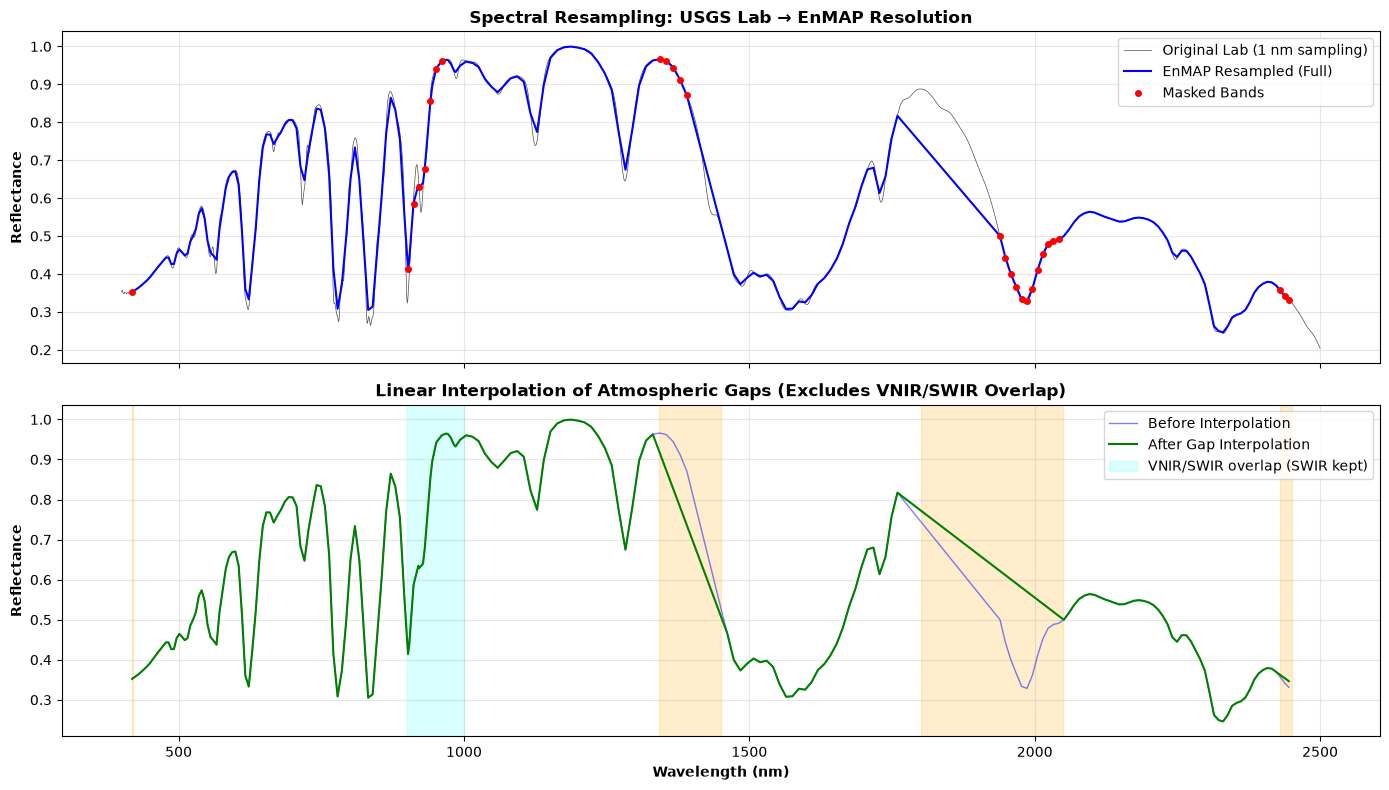

In [8]:
from src.ree_wavelet_viz import plot_spectral_resampling

plot_spectral_resampling(wl_bst_usgs, refl_bst_usgs,
                          wl_enmap_full, bst_usgs_enmap,
                          refl_enmap_interp, mask)


## Section 5: Discrete Wavelet Transform (DWT) Theory

**Mathematical Framework**

The DWT decomposes a signal into orthogonal components at different scales through recursive filtering:

$$
\begin{align}
A_j[n] &= \sum_k h[k-2n] A_{j-1}[k] \quad \text{(Approximation: low-pass)} \\
D_j[n] &= \sum_k g[k-2n] A_{j-1}[k] \quad \text{(Detail: high-pass)}
\end{align}
$$

where $h$ and $g$ are the low-pass and high-pass filters derived from the mother wavelet.

**Mother Wavelet Selection**

**Daubechies 4 (db4)**: Compact support, 4 vanishing moments
   - Good for detecting localized polynomial trends
   - Filter length: 8 coefficients

**Scale-to-Wavelength Mapping**

For a signal with mean sampling interval $\Delta\lambda_{\text{sampling}}$ (nm), each DWT level $j$ captures features at characteristic width:

$$
\text{Characteristic width at level } j \approx 2^j \cdot \Delta\lambda_{\text{sampling}}
$$

For EnMAP clean bands (mean sampling ~9 nm):
- **D1** (Detail 1): $2^1 \times 9 \approx 18$ nm features → **REE absorptions**
- **D2** (Detail 2): $2^2 \times 9 \approx 36$ nm features → **REE absorptions**
- **D3** (Detail 3): $2^3 \times 9 \approx 72$ nm features → Transition to broad features
- **D4** (Detail 4): $2^4 \times 9 \approx 144$ nm features → **Iron oxides, continuum**
- **A** (Approximation): Low-frequency background

In [9]:
# Display available wavelets and their properties
from src.ree_wavelet_viz import summarize_wavelets

wavelet_info = summarize_wavelets(
    wl_enmap_full,
    test_wavelets=['haar', 'db4', 'sym6'],
    max_level_wavelet='db4',
    max_display_level=6,
)

Wavelet Families for DWT:

HAAR:
  Family: Haar
  Vanishing moments: 1
  Filter length: 2
  Symmetry: asymmetric
  Orthogonal: True
  Biorthogonal: True

DB4:
  Family: Daubechies
  Vanishing moments: 4
  Filter length: 8
  Symmetry: asymmetric
  Orthogonal: True
  Biorthogonal: True

SYM6:
  Family: Symlets
  Vanishing moments: 6
  Filter length: 12
  Symmetry: near symmetric
  Orthogonal: True
  Biorthogonal: True

Signal properties:
  Number of clean bands: 224
  Mean sampling interval: 9.09 nm
  Maximum DWT level: 5

Characteristic widths (nm):
  scale_j ≈ 2^j × Δλ_sampling
  --------------------------------------------------
  D1: 2^1 × 9.09 = 18.2 nm
  D2: 2^2 × 9.09 = 36.4 nm
  D3: 2^3 × 9.09 = 72.7 nm
  D4: 2^4 × 9.09 = 145.4 nm
  D5: 2^5 × 9.09 = 290.9 nm

  → D1-D2 target REE features (10-50 nm FWHM)
  → D3-D4 capture broader features (Fe oxides, continuum)


## Section 6: Perform DWT on Bastnäsite Spectrum

Apply multi-level DWT to identify at which scales REE absorption features emerge.

In [10]:
from src.ree_wavelet_viz import perform_dwt_multilevel


# Perform DWT with multiple wavelets
DWT_LEVEL = 5
dwt_results = {}

for wavelet in ['haar', 'db4', 'sym6']:
    coeffs, recons = perform_dwt_multilevel(
        refl_enmap_interp, wavelet=wavelet, level=DWT_LEVEL
    )
    dwt_results[wavelet] = {'coeffs': coeffs, 'recons': recons}
    
    print(f"\nDWT with {wavelet.upper()}:")
    print(f"  Levels: {DWT_LEVEL}")
    print(f"  Coefficients shapes:")
    for i, c in enumerate(coeffs):
        name = 'A' if i == 0 else f'D{len(coeffs)-i}'
        print(f"    {name}: {c.shape}")

print("\n✓ DWT decomposition complete for all wavelets")


DWT with HAAR:
  Levels: 5
  Coefficients shapes:
    A: (7,)
    D5: (7,)
    D4: (14,)
    D3: (28,)
    D2: (56,)
    D1: (112,)

DWT with DB4:
  Levels: 5
  Coefficients shapes:
    A: (13,)
    D5: (13,)
    D4: (20,)
    D3: (34,)
    D2: (61,)
    D1: (115,)

DWT with SYM6:
  Levels: 5
  Coefficients shapes:
    A: (17,)
    D5: (17,)
    D4: (24,)
    D3: (37,)
    D2: (64,)
    D1: (117,)

✓ DWT decomposition complete for all wavelets


C:\Users\esppr\anaconda3\envs\bachelor-thesis\Lib\site-packages\pywt\_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


### Visualize DWT Decomposition

Plot original spectrum and each detail/approximation level to identify where REE features appear.

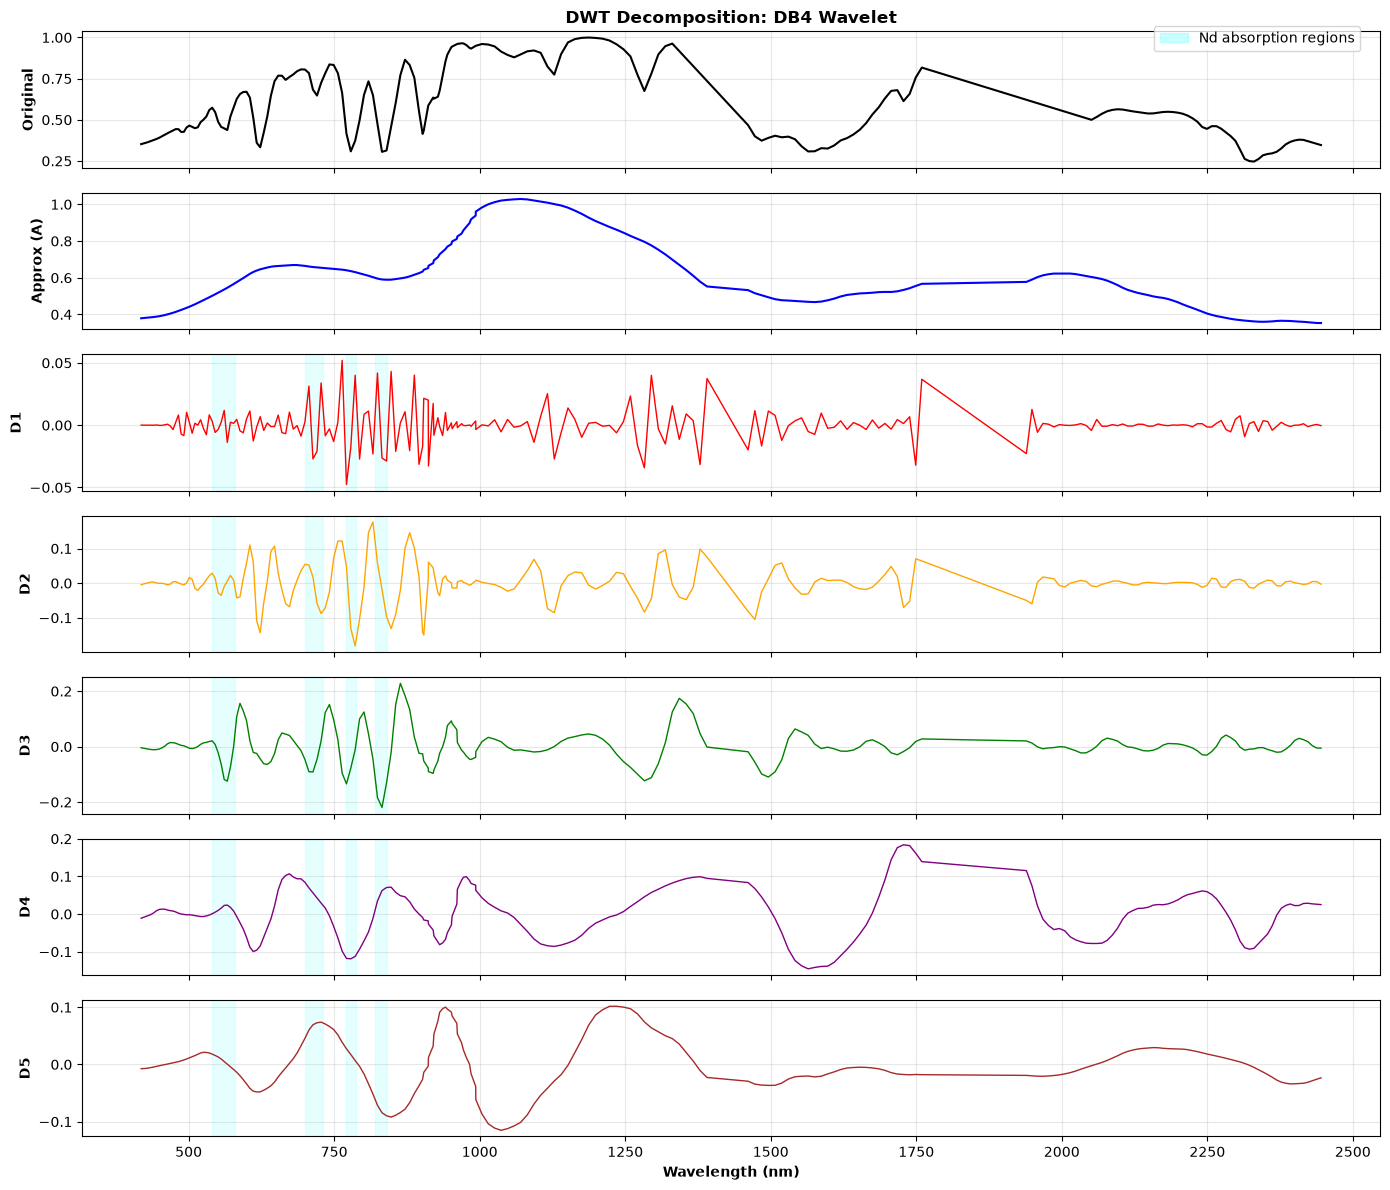

✓ DWT decomposition visualized for db4
  Cyan regions mark known Nd absorption features


In [11]:
from src.ree_wavelet_viz import plot_dwt_decomposition

plot_dwt_decomposition(wl_enmap_full, refl_enmap_interp, dwt_results, wavelet='db4')

## Section 7: Continuous Wavelet Transform (CWT) Theory

**Mathematical Framework**

The CWT computes correlation between signal and scaled/translated mother wavelet:

$$
W(a, b) = \frac{1}{\sqrt{|a|}} \int_{-\infty}^{\infty} f(\lambda) \psi^*\left(\frac{\lambda - b}{a}\right) d\lambda
$$

where:
- $a$ = scale parameter (inversely related to frequency)
- $b$ = translation parameter (wavelength position)
- $\psi$ = mother wavelet

**Mother Wavelet Selection**

For symmetric absorption features, we test:

1. **Mexican Hat (mexh)**: 2nd derivative of Gaussian
   $$
   \psi_{\text{mexh}}(t) = \frac{2}{\sqrt{3\sigma}\pi^{1/4}} \left(1 - \frac{t^2}{\sigma^2}\right) e^{-t^2/(2\sigma^2)}
   $$
   - Matches Gaussian absorption profile
   - Recommended for narrow, symmetric features [17]

2. **Morlet**: Complex sinusoid modulated by Gaussian
   $$
   \psi_{\text{morl}}(t) = e^{i\omega_0 t} e^{-t^2/2}
   $$
   - Good frequency localization
   - Phase information available

**Scale-to-FWHM Mapping**

For Mexican Hat wavelet, the relationship between CWT scale and spectral FWHM is:

$$
\text{FWHM} \approx 2 \sqrt{2\ln 2} \cdot a \cdot \Delta\lambda_{\text{sampling}}
$$

For EnMAP sampling (~9 nm), we design scales to match REE feature widths (10-50 nm).

In [12]:
# -----------------------------
# Nd absorption bands
# -----------------------------
ND_BANDS = [(540, 580), (700, 730), (770, 788), (820, 840), (2320, 2340)]

# -----------------------------
# Correct scale design (CRITICAL FIX)
# -----------------------------
mean_sampling = np.mean(np.diff(wl_enmap_full))

# restrict to physically meaningful REE absorption widths
fwhm_target_nm = np.array([10, 12, 15, 18, 20, 25, 30, 40, 50])
#np.array([10, 20, 30, 50, 80, 120, 200, 300, 500]) full fhwm
CWT_SCALES = fwhm_target_nm / (2.355 * mean_sampling)

print("CWT SCALE DESIGN (FIXED FOR ABSORPTION PHYSICS)")
print("="*60)
for s, f in zip(CWT_SCALES, fwhm_target_nm):
    print(f"scale={s:.3f} → FWHM≈{f} nm")

CWT SCALE DESIGN (FIXED FOR ABSORPTION PHYSICS)
scale=0.467 → FWHM≈10 nm
scale=0.561 → FWHM≈12 nm
scale=0.701 → FWHM≈15 nm
scale=0.841 → FWHM≈18 nm
scale=0.934 → FWHM≈20 nm
scale=1.168 → FWHM≈25 nm
scale=1.402 → FWHM≈30 nm
scale=1.869 → FWHM≈40 nm
scale=2.336 → FWHM≈50 nm


## Section 8: Perform CWT on Bastnäsite Spectrum

Apply CWT with Mexican Hat and Morlet wavelets to create scale-wavelength maps showing where narrow features occur.

**Note**: Scale normalization is optional and defaults to OFF (False) as it can sometimes obscure absolute feature strength.

In [13]:
def perform_cwt(signal, scales, wavelet='mexh'):
    coeffs, _ = pywt.cwt(signal, scales, wavelet)
    power = np.abs(coeffs) ** 2
    return coeffs, power


cwt_results = {}

for wavelet in ['mexh', 'morl', 'cgau2']:
    coeffs, power = perform_cwt(refl_enmap_interp, CWT_SCALES, wavelet)

    cwt_results[wavelet] = {
        "coeffs": coeffs,
        "power": power
    }

    print(f"\n{wavelet}:")
    print("shape =", power.shape)


mexh:
shape = (9, 224)

morl:
shape = (9, 224)

cgau2:
shape = (9, 224)


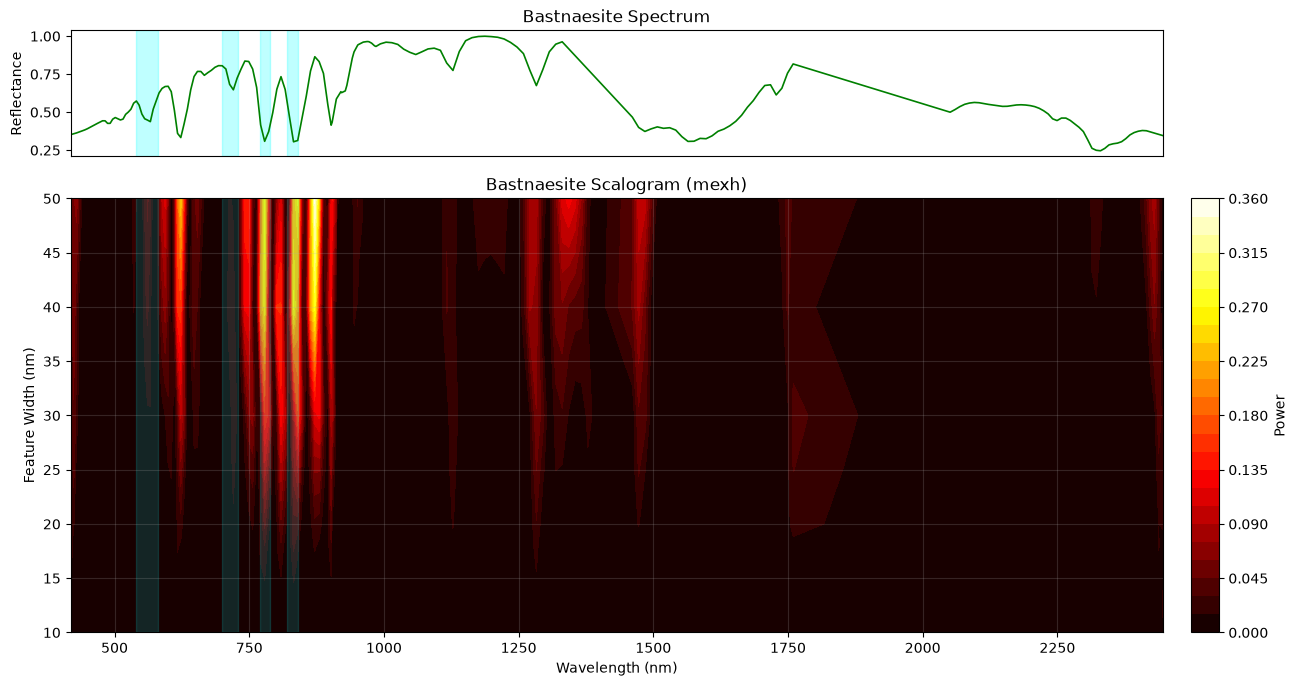

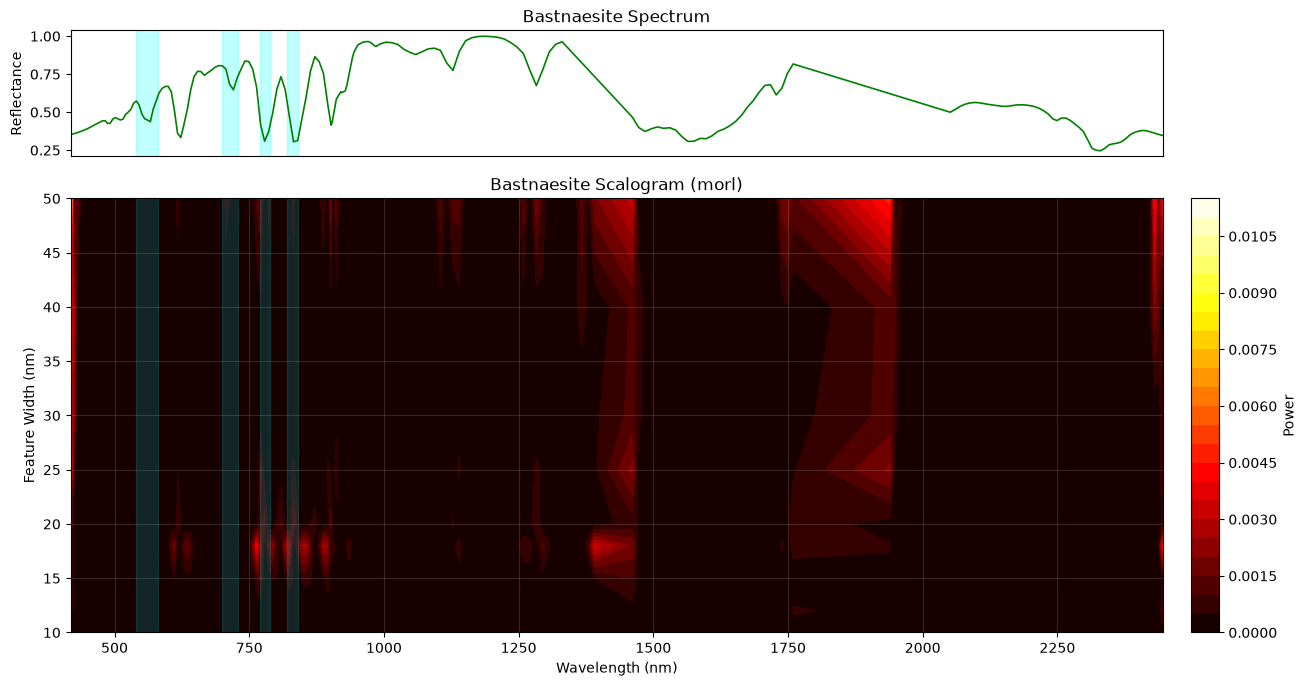

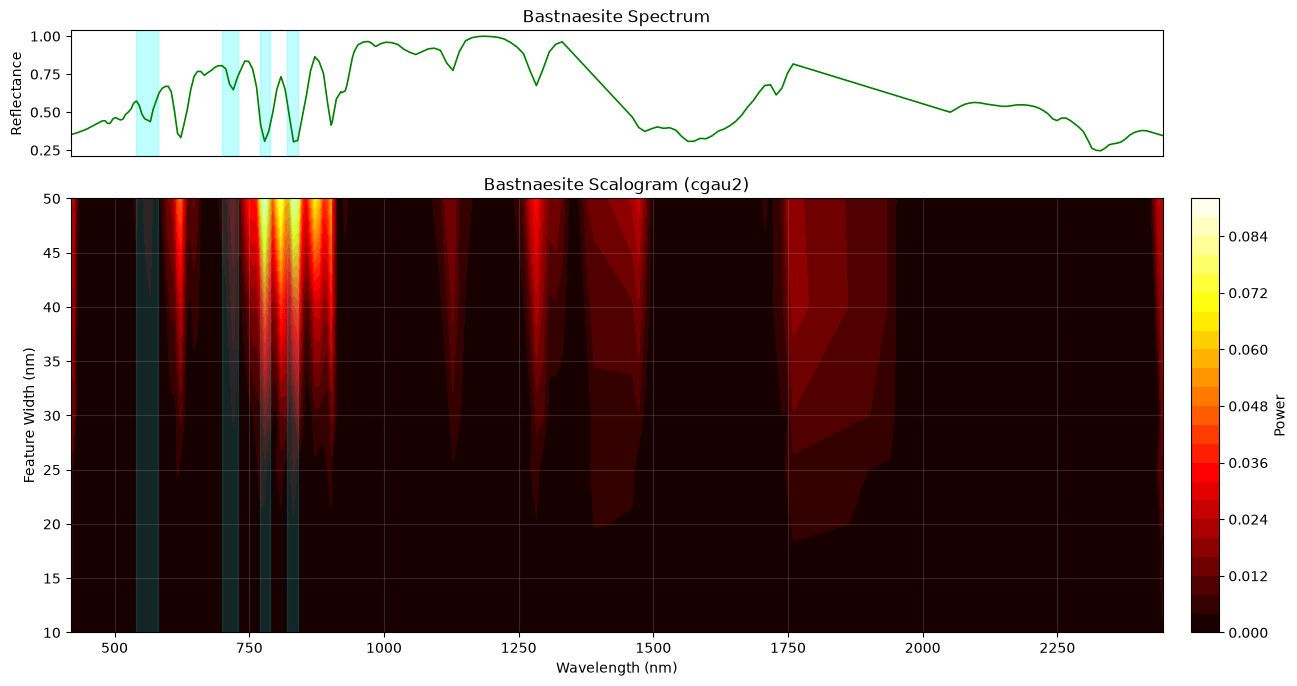

In [14]:
from src.ree_wavelet_viz import plot_scalogram_with_top_spectrum

# ---------------- Run ----------------
for w in ['mexh', 'morl', 'cgau2']:

    plot_scalogram_with_top_spectrum(
        cwt_results[w]["power"],
        CWT_SCALES,
        wl_enmap_full,
        refl_enmap_interp,
        title=f"Bastnaesite Scalogram ({w})"
    )